##  Assignment 2: Min-Hash and LSH

Name : Arpita Kundu,
Roll No : M25DE1004

## MIN-HASHING AND LSH
 For the following questions, use the D1.txt , D2.txt , D3.txt , and D4.txt files in the minhash directory.

 ## Q-1. Create k-Grams:

 You will construct several types of k-grams for all documents. All documents only have at
most 27 characters: all lowercase letters and space. The space counts as a character in
character k-grams.

+ Construct 2-grams based on characters for all documents.
+ Construct 3-grams based on characters for all documents.
+ Construct 2-grams based on words for all documents.


Remember that you should only store each k-gram once. Duplicates are ignored.



**PART - A:**

Using 3-grams to build a min-hash signature for documents D1 and D2 using:
t = 20, 60, 150, 300, 600 hash functions.You should report 5 numbers.


**PART - B:**

Compute the Jaccard similarity between all pairs of documents for each type of k-gram. You should report:

3 × 6 = 18

different numbers.

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [21]:
import os
from itertools import combinations
import random

base_path = "/content/drive/MyDrive/minhash/minhash/"

document_files = ["D1.txt", "D2.txt", "D3.txt", "D4.txt"]

document_store = {}

# Reading files
for file_name in document_files:
    file_path = os.path.join(base_path, file_name)
    with open(file_path, "r", encoding="utf-8") as file_obj:
        document_store[file_name] = file_obj.read().lower().strip()

# Printing first 50 characters
for doc_id, text_data in document_store.items():
    print(f"{doc_id}: {text_data[:50]}...")


D1.txt: apple ceo tim cook is spending some time in canada...
D2.txt: apple ceo tim cook is spending some time in canada...
D3.txt: as part of his one day tour of canada yesterday ti...
D4.txt: president trump who warned as a candidate about th...


In [20]:
def generate_word_ngrams(content, size):
    token_list = content.split()
    word_sequences = set()

    for index in range(len(token_list) - size + 1):
        sequence = " ".join(token_list[index:index + size])
        word_sequences.add(sequence)

    return word_sequences


def generate_char_ngrams(content, size):
    char_sequences = set()

    for index in range(len(content) - size + 1):
        sequence = content[index:index + size]
        char_sequences.add(sequence)

    return char_sequences


# Store all n-gram results
ngram_storage = {}

for document_id, document_text in document_store.items():
    ngram_storage[document_id] = {
        "char_2gram": generate_char_ngrams(document_text, 2),
        "char_3gram": generate_char_ngrams(document_text, 3),
        "word_2gram": generate_word_ngrams(document_text, 2),
    }


# Count n-grams
ngram_statistics = {}

for document_id, ngram_sets in ngram_storage.items():
    ngram_statistics[document_id] = {}

    for gram_label, gram_values in ngram_sets.items():
        ngram_statistics[document_id][gram_label] = len(gram_values)



for document_id, stats in ngram_statistics.items():
    print(f"{document_id}: {stats}")


D1.txt: {'char_2gram': 263, 'char_3gram': 765, 'word_2gram': 279}
D2.txt: {'char_2gram': 262, 'char_3gram': 762, 'word_2gram': 278}
D3.txt: {'char_2gram': 269, 'char_3gram': 828, 'word_2gram': 337}
D4.txt: {'char_2gram': 255, 'char_3gram': 698, 'word_2gram': 232}


In [23]:
def compute_jaccard(set_a, set_b):
    common_elements = set_a.intersection(set_b)
    combined_elements = set_a.union(set_b)

    if len(combined_elements) == 0:
        return 0

    return len(common_elements) / len(combined_elements)

document_ids = list(ngram_storage.keys()) #  Get document identifiers
document_pairs = []                    # Generate unique document combinations

for index_a in range(len(document_ids)):
    for index_b in range(index_a + 1, len(document_ids)):
        document_pairs.append((document_ids[index_a], document_ids[index_b]))


# Prepare similarity container
similarity_results = {
    "char_2gram": {},
    "char_3gram": {},
    "word_2gram": {}
}


# Compute Jaccard similarity
for gram_category in similarity_results.keys():
    for doc_a, doc_b in document_pairs:
        set_one = ngram_storage[doc_a][gram_category]
        set_two = ngram_storage[doc_b][gram_category]

        similarity_results[gram_category][(doc_a, doc_b)] = compute_jaccard(set_one, set_two)


for gram_category, score_map in similarity_results.items():
    print(f"\nJaccard Similarity for {gram_category}:")

    for pair_label, score_value in score_map.items():
        print(f"{pair_label}: {score_value:.4f}")



Jaccard Similarity for char_2gram:
('D1.txt', 'D2.txt'): 0.9811
('D1.txt', 'D3.txt'): 0.8157
('D1.txt', 'D4.txt'): 0.6444
('D2.txt', 'D3.txt'): 0.8000
('D2.txt', 'D4.txt'): 0.6413
('D3.txt', 'D4.txt'): 0.6530

Jaccard Similarity for char_3gram:
('D1.txt', 'D2.txt'): 0.9780
('D1.txt', 'D3.txt'): 0.5804
('D1.txt', 'D4.txt'): 0.3051
('D2.txt', 'D3.txt'): 0.5680
('D2.txt', 'D4.txt'): 0.3059
('D3.txt', 'D4.txt'): 0.3121

Jaccard Similarity for word_2gram:
('D1.txt', 'D2.txt'): 0.9408
('D1.txt', 'D3.txt'): 0.1823
('D1.txt', 'D4.txt'): 0.0302
('D2.txt', 'D3.txt'): 0.1737
('D2.txt', 'D4.txt'): 0.0303
('D3.txt', 'D4.txt'): 0.0161


## Q -2. Min-Hashing:

We will consider a hash family ( H ) so that any hash function ( h ∈H ) maps from:  h : k-grams → [m]
for ( m ) large enough (To be extra cautious, use ( m greater than 10,000 )).

**PART - A:**

Using 3-grams to build a min-hash signature for documents D1 and D2 using:

t = 20, 60, 150, 300, 600 hash functions.
For each value of ( t ), report the approximate Jaccard similarity between the pair of documents D1 and D2, estimating the Jaccard similarity.
You should report 5 numbers.

**PART - B:**

What seems to be a good value for ( t )? You may run more experiments. Justify your answer in terms of both accuracy and time.

In [27]:
# Generate 3-character n-grams for selected documents

doc1_trigrams = generate_char_ngrams(document_store["D1.txt"], 3)
doc2_trigrams = generate_char_ngrams(document_store["D2.txt"], 3)

print("Total 3-character grams in D1.txt:", len(doc1_trigrams))
print("Total 3-character grams in D2.txt:", len(doc2_trigrams))


Total 3-character grams in D1.txt: 765
Total 3-character grams in D2.txt: 762


In [30]:
def create_hash_coefficients(total_hashes, modulus=10000):
    random.seed(42)
    coefficient_list = []

    for _ in range(total_hashes):
        coef_a = random.randint(1, modulus - 1)
        coef_b = random.randint(0, modulus - 1)
        coefficient_list.append((coef_a, coef_b))

    return coefficient_list


def compute_minhash_signature(ngram_set, coefficient_pairs, modulus=10000):
    signature_vector = []

    for coef_a, coef_b in coefficient_pairs:
        minimum_value = min(((coef_a * hash(item) + coef_b) % modulus) for item in ngram_set)
        signature_vector.append(minimum_value)

    return signature_vector


hash_counts = [20, 60, 150, 300, 600]

estimated_similarity = {}

for num_hashes in hash_counts:
    coeffs = create_hash_coefficients(num_hashes)

    signature_doc1 = compute_minhash_signature(doc1_trigrams, coeffs)
    signature_doc2 = compute_minhash_signature(doc2_trigrams, coeffs)

    matching_positions = sum(
        1 for idx in range(num_hashes)
        if signature_doc1[idx] == signature_doc2[idx]
    )

    estimated_similarity[num_hashes] = matching_positions / num_hashes



print("\nEstimated Jaccard Similarity between D1.txt and D2.txt using MinHash:\n")

for h_count, similarity_value in estimated_similarity.items():
    print(f"Number of hashes = {h_count} --> Similarity ≈ {similarity_value:.4f}")



Estimated Jaccard Similarity between D1.txt and D2.txt using MinHash:

Number of hashes = 20 --> Similarity ≈ 1.0000
Number of hashes = 60 --> Similarity ≈ 0.9833
Number of hashes = 150 --> Similarity ≈ 0.9867
Number of hashes = 300 --> Similarity ≈ 0.9867
Number of hashes = 600 --> Similarity ≈ 0.9867


## Q - 3. LSH:

Consider computing an LSH using:
t = 160 hash functions.

We want to find all document pairs with Jaccard similarity above:
τ = .7


**PART - A:**

Use the formula mentioned in class and the notes to estimate the best values of hash functions ( b ) within each of the ( r ) bands to provide the S-curve:   f(s) = 1 − (1 − s
b
)
r

 with good separation at (τ). Report these values.


**PART - B:**

Using your choice of ( r ) and ( b ) and ( f(⋅) ), what is the probability of each pair of the four
documents (using 3-grams) being estimated to have a similarity greater than ( τ )? Report 6 numbers.


In [29]:
def s_curve_probability(similarity, bands, rows):
    return 1 - (1 - similarity ** bands) ** rows


total_hashes = 160
threshold = 0.7

similarity_range = [value / 100 for value in range(101)]
band_row_options = [(20, 8), (16, 10), (10, 16), (8, 20)]

curve_results = {}

for rows, bands in band_row_options:
    probability_values = [
        s_curve_probability(sim, bands, rows)
        for sim in similarity_range
    ]

    curve_results[(rows, bands)] = probability_values

    print(f"\nS-curve values when rows={rows} and bands={bands}:\n")

    for sim_value, prob in zip(similarity_range, probability_values):
        print(f"Similarity = {sim_value:.2f} --> Probability = {prob:.4f}")


optimal_choice = None
smallest_gap = float("inf")

for (rows, bands), _ in curve_results.items():
    difference = abs(s_curve_probability(threshold, bands, rows) - 0.5)

    if difference < smallest_gap:
        smallest_gap = difference
        optimal_choice = (rows, bands)


print("\nOptimal (rows, bands) configuration near threshold:")
print(f"Threshold = {threshold}")
print(f"Selected rows = {optimal_choice[0]}")
print(f"Selected bands = {optimal_choice[1]}")



S-curve values when rows=20 and bands=8:

Similarity = 0.00 --> Probability = 0.0000
Similarity = 0.01 --> Probability = 0.0000
Similarity = 0.02 --> Probability = 0.0000
Similarity = 0.03 --> Probability = 0.0000
Similarity = 0.04 --> Probability = 0.0000
Similarity = 0.05 --> Probability = 0.0000
Similarity = 0.06 --> Probability = 0.0000
Similarity = 0.07 --> Probability = 0.0000
Similarity = 0.08 --> Probability = 0.0000
Similarity = 0.09 --> Probability = 0.0000
Similarity = 0.10 --> Probability = 0.0000
Similarity = 0.11 --> Probability = 0.0000
Similarity = 0.12 --> Probability = 0.0000
Similarity = 0.13 --> Probability = 0.0000
Similarity = 0.14 --> Probability = 0.0000
Similarity = 0.15 --> Probability = 0.0000
Similarity = 0.16 --> Probability = 0.0000
Similarity = 0.17 --> Probability = 0.0000
Similarity = 0.18 --> Probability = 0.0000
Similarity = 0.19 --> Probability = 0.0000
Similarity = 0.20 --> Probability = 0.0001
Similarity = 0.21 --> Probability = 0.0001
Similarity 

In [32]:
def build_trigrams(input_text):
    return {input_text[idx:idx + 3] for idx in range(len(input_text) - 2)}


# Create trigram sets for each document
trigram_map = {
    document_label: build_trigrams(text_data)
    for document_label, text_data in document_store.items()
}

similarity_scores = {}

for doc_a, doc_b in combinations(list(trigram_map.keys()), 2):
    score_value = compute_jaccard(trigram_map[doc_a], trigram_map[doc_b])
    similarity_scores[(doc_a, doc_b)] = score_value


rows = 20
bands = 8
threshold = 0.7

probability_estimates = {}

print("\nProbability that similarity exceeds the chosen threshold:\n")

for pair_key, similarity_value in similarity_scores.items():
    probability_value = s_curve_probability(similarity_value, bands, rows)
    probability_estimates[pair_key] = probability_value

    print(f"Pair {pair_key} --> Probability ≈ {probability_value:.4f}")



Probability that similarity exceeds the chosen threshold:

Pair ('D1.txt', 'D2.txt') --> Probability ≈ 1.0000
Pair ('D1.txt', 'D3.txt') --> Probability ≈ 0.2282
Pair ('D1.txt', 'D4.txt') --> Probability ≈ 0.0015
Pair ('D2.txt', 'D3.txt') --> Probability ≈ 0.1959
Pair ('D2.txt', 'D4.txt') --> Probability ≈ 0.0015
Pair ('D3.txt', 'D4.txt') --> Probability ≈ 0.0018


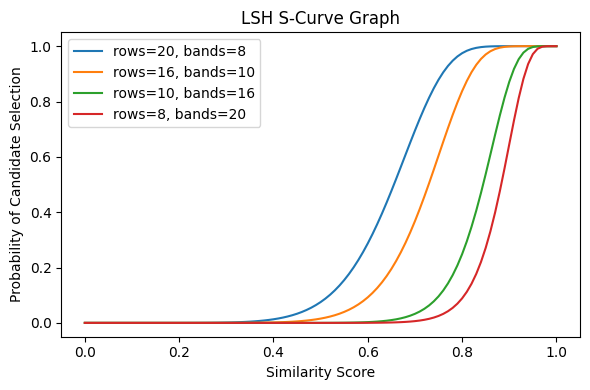

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for (rows, bands), probabilities in curve_results.items():
    plt.plot(
        similarity_range,
        probabilities,
        label=f"rows={rows}, bands={bands}"
    )

plt.title("LSH S-Curve Graph")
plt.xlabel("Similarity Score")
plt.ylabel("Probability of Candidate Selection")
plt.legend()
plt.tight_layout()
plt.show()


## Q - 4. Min-Hashing on MovieLens dataset:

Implement Min-Hashing on the older MovieLens 100k dataset (5MB), which consists of a set of 943 users who have rated 1682 movies. You can download the data from:

http://www.grouplens.org/node/73


Read the Readme file for details about the data, and process it as you need.
For this exercise, we only care about the set of movies that a user has rated and not the ratings. We want to compute the Jaccard similarity between the users.

Compute the exact Jaccard similarity for all pairs of users, and output the pairs of users that have a similarity of at least 0.5.

Then, compute the min-hash signatures for the users and compute the approximate Jaccard similarity.

Use:
+ 50 hash functions
+ 100 hash functions
+ 200 hash functions
For each value, output the pairs that have an estimated similarity of at least 0.5 and report the number of false positives and false negatives that you obtain.

For the false positives and negatives, report the averages for 5 different runs.

In [38]:
def load_movie_ratings(file_location):
    user_movies_map = {}

    with open(file_location, "r") as data_file:
        for record in data_file:
            parts = record.split()

            user_id = int(parts[0])
            movie_id = int(parts[1])

            if user_id not in user_movies_map:
                user_movies_map[user_id] = set()

            user_movies_map[user_id].add(movie_id)

    return user_movies_map



dataset_path = "/content/drive/MyDrive/ml-100k/ml-100k/u.data"

user_movie_data = load_movie_ratings(dataset_path)

similarity_results = {}
user_list = list(user_movie_data.keys())

for idx1 in range(len(user_list)):
    for idx2 in range(idx1 + 1, len(user_list)):
        user_a = user_list[idx1]
        user_b = user_list[idx2]


        intersection_size = len(
            user_movie_data[user_a].intersection(user_movie_data[user_b])
        )
        union_size = len(
            user_movie_data[user_a].union(user_movie_data[user_b])
        )

        jaccard_score = intersection_size / union_size

        if jaccard_score >= 0.5:
            similarity_results[(user_a, user_b)] = jaccard_score


print("\nUser pairs with Jaccard similarity of 0.5 or higher:\n")

for user_pair, score in similarity_results.items():
    print(f"Users {user_pair[0]} & {user_pair[1]} --> Similarity Score = {score:.4f}")



User pairs with Jaccard similarity of 0.5 or higher:

Users 197 & 600 --> Similarity Score = 0.5000
Users 197 & 826 --> Similarity Score = 0.5130
Users 328 & 788 --> Similarity Score = 0.6730
Users 408 & 898 --> Similarity Score = 0.8387
Users 451 & 489 --> Similarity Score = 0.5333
Users 489 & 587 --> Similarity Score = 0.6299
Users 554 & 764 --> Similarity Score = 0.5170
Users 600 & 826 --> Similarity Score = 0.5455
Users 674 & 879 --> Similarity Score = 0.5217
Users 800 & 879 --> Similarity Score = 0.5000


In [37]:
def generate_minhash_signature(movie_set, total_hashes):
    max_movie_id = 1682
    signature_vector = []

    for hash_index in range(total_hashes):
        current_min = float("inf")

        for movie_id in movie_set:
            hash_result = (3 * movie_id + 7 * hash_index) % max_movie_id

            if hash_result < current_min:
                current_min = hash_result

        signature_vector.append(current_min)

    return signature_vector


def build_all_signatures(total_hashes):
    user_signatures = {}

    for user_id, movie_set in user_movie_data.items():
        user_signatures[user_id] = generate_minhash_signature(
            movie_set, total_hashes
        )

    return user_signatures


def estimate_jaccard(signature_a, signature_b):
    equal_positions = sum(
        1 for idx in range(len(signature_a))
        if signature_a[idx] == signature_b[idx]
    )
    return equal_positions / len(signature_a)


def approximate_jaccard_similarity(total_hashes):
    signature_dict = build_all_signatures(total_hashes)
    similarity_estimates = {}

    for idx1 in range(len(user_list)):
        for idx2 in range(idx1 + 1, len(user_list)):
            user_a = user_list[idx1]
            user_b = user_list[idx2]

            approx_score = estimate_jaccard(
                signature_dict[user_a],
                signature_dict[user_b]
            )

            if approx_score >= 0.5:
                similarity_estimates[(user_a, user_b)] = approx_score

    print(f"\nMinHash-based Jaccard estimates (threshold ≥ 0.5) using {total_hashes} hash functions:\n")

    for user_pair, score in similarity_estimates.items():
        print(f"Users {user_pair[0]} & {user_pair[1]} -> Approx. Similarity = {score:.4f}")

    return similarity_estimates


for hash_count in [50, 100, 200]:
    approx_results = approximate_jaccard_similarity(hash_count)

    false_positives = sum(
        1 for pair in approx_results
        if pair not in similarity_results
    )

    false_negatives = sum(
        1 for pair in similarity_results
        if pair not in approx_results
    )

    print(f"\nPerformance Summary for {hash_count} Hash Functions:")
    print(f"False Positives Count: {false_positives}")
    print(f"False Negatives Count: {false_negatives}")



MinHash-based Jaccard estimates (threshold ≥ 0.5) using 50 hash functions:

Users 298 & 897 -> Approx. Similarity = 0.5400
Users 6 & 234 -> Approx. Similarity = 0.5200
Users 6 & 59 -> Approx. Similarity = 0.5000
Users 6 & 537 -> Approx. Similarity = 0.5200
Users 194 & 716 -> Approx. Similarity = 0.5600
Users 234 & 59 -> Approx. Similarity = 0.5200
Users 234 & 450 -> Approx. Similarity = 0.5200
Users 234 & 474 -> Approx. Similarity = 0.5000
Users 234 & 537 -> Approx. Similarity = 0.5000
Users 234 & 716 -> Approx. Similarity = 0.5400
Users 308 & 13 -> Approx. Similarity = 0.5000
Users 308 & 650 -> Approx. Similarity = 0.5000
Users 63 & 287 -> Approx. Similarity = 0.6800
Users 63 & 168 -> Approx. Similarity = 0.5600
Users 63 & 294 -> Approx. Similarity = 0.5000
Users 63 & 137 -> Approx. Similarity = 0.5000
Users 63 & 75 -> Approx. Similarity = 0.5800
Users 63 & 396 -> Approx. Similarity = 0.5000
Users 63 & 432 -> Approx. Similarity = 0.5200
Users 63 & 534 -> Approx. Similarity = 0.6000
U

##   Q - 5. LSH on MovieLens dataset:

Break up the signature table into ( b ) bands with ( r ) hash functions per band and implement Locality Sensitive Hashing.

The goal is to find candidate pairs with a similarity of at least 0.6.

Experiment with:

+ ( r = 5, b = 10 ) for the table with the 50 hash functions
+ ( r = 5, b = 20 ) for the table with the 100 hash functions
+ ( r = 5, b = 40 ) and ( r = 10, b = 20 ) for the table with the 200 hash functions

Report the number of false positives and false negatives, taking the average over 5 runs.

How do these numbers change if we want a similarity of at least 0.8?

In [39]:
import numpy as np
from itertools import combinations


def perform_lsh(signature_dict, rows_per_band, total_bands, sim_threshold=0.6):
    band_collections = []

    for band_index in range(total_bands):
        bucket_map = {}

        for user_id, signature in signature_dict.items():
            band_slice = tuple(
                signature[band_index * rows_per_band : (band_index + 1) * rows_per_band]
            )

            if band_slice not in bucket_map:
                bucket_map[band_slice] = []

            bucket_map[band_slice].append(user_id)

        band_collections.append(bucket_map)

    candidate_pairs = set()

    for band in band_collections:
        for grouped_users in band.values():
            if len(grouped_users) > 1:
                for user_pair in combinations(grouped_users, 2):
                    candidate_pairs.add(tuple(sorted(user_pair)))

    return candidate_pairs


def evaluate_false_rates(predicted_pairs, true_similarities, sim_threshold):
    true_positive_pairs = {
        pair for pair, score in true_similarities.items()
        if score >= sim_threshold
    }

    false_positives = predicted_pairs - true_positive_pairs
    false_negatives = true_positive_pairs - predicted_pairs

    return len(false_positives), len(false_negatives)


def run_lsh_experiments(hash_count, rows_per_band, total_bands,
                        sim_threshold=0.6, repetitions=5):

    fp_results = []
    fn_results = []

    for _ in range(repetitions):
        signature_data = build_all_signatures(hash_count)
        predicted_pairs = perform_lsh(signature_data,
                                      rows_per_band,
                                      total_bands,
                                      sim_threshold)

        fp_count, fn_count = evaluate_false_rates(
            predicted_pairs,
            similarity_results,
            sim_threshold
        )

        fp_results.append(fp_count)
        fn_results.append(fn_count)

    return np.mean(fp_results), np.mean(fn_results)


experiment_settings = [
    (50, 5, 10),
    (100, 5, 20),
    (200, 5, 40),
    (200, 10, 20)
]

threshold_values = [0.6, 0.8]


for threshold_value in threshold_values:
    print(f"\nLSH Evaluation Summary (Similarity Threshold = {threshold_value})")

    for hash_count, rows, bands in experiment_settings:
        print(f"\nConfiguration -> Hashes: {hash_count}, Rows per Band: {rows}, Bands: {bands}")

        avg_fp, avg_fn = run_lsh_experiments(
            hash_count,
            rows,
            bands,
            threshold_value
        )

        print(f"Mean False Positives: {avg_fp:.2f}")
        print(f"Mean False Negatives: {avg_fn:.2f}")



LSH Evaluation Summary (Similarity Threshold = 0.6)

Configuration -> Hashes: 50, Rows per Band: 5, Bands: 10
Mean False Positives: 45412.00
Mean False Negatives: 1.00

Configuration -> Hashes: 100, Rows per Band: 5, Bands: 20
Mean False Positives: 66919.00
Mean False Negatives: 1.00

Configuration -> Hashes: 200, Rows per Band: 5, Bands: 40
Mean False Positives: 121499.00
Mean False Negatives: 0.00

Configuration -> Hashes: 200, Rows per Band: 10, Bands: 20
Mean False Positives: 32080.00
Mean False Negatives: 0.00

LSH Evaluation Summary (Similarity Threshold = 0.8)

Configuration -> Hashes: 50, Rows per Band: 5, Bands: 10
Mean False Positives: 45413.00
Mean False Negatives: 0.00

Configuration -> Hashes: 100, Rows per Band: 5, Bands: 20
Mean False Positives: 66920.00
Mean False Negatives: 0.00

Configuration -> Hashes: 200, Rows per Band: 5, Bands: 40
Mean False Positives: 121501.00
Mean False Negatives: 0.00

Configuration -> Hashes: 200, Rows per Band: 10, Bands: 20
Mean False Pos